# Trabalho Final | Ciência de Dados


## Escolha da Base de Dados

Resumo da Base de Dados "Heart Disease" (Doença Cardíaca)

1. **Objetivo Principal:** O objetivo primário desta base de dados é prever a presença de doença cardíaca em um paciente com base em diversos atributos clínicos e demográficos. É uma tarefa de classificação binária, onde o alvo é prever a presença (1) ou ausência (0) da doença.

2. **Origem dos Dados:** Esta base de dados é oriunda do repositório UCI Machine Learning e é um subconjunto de dados coletados no Cleveland Clinic Foundation.

**Estrutura da Base:**

*   **Instâncias:** A base de dados carregada possui 303 registros (pacientes).
*   **Atributos (Colunas):** São 13 atributos (ou features) utilizados para fazer a previsão e 1 atributo alvo ('target').


**Observações:**

*   A base de dados contém valores faltantes, representados por '?'. No código fornecido, estes foram convertidos para `NaN`.
*   A variável alvo foi binarizada para simplificar a classificação, onde qualquer valor maior que 0 na base original foi convertido para 1.

In [2]:
import pandas as pd

# URL do arquivo de dados
url_heart = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Nomes das colunas (conforme a documentação)
colunas_heart = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Carregar os dados usando pandas
# O arquivo original usa '?' para dados faltantes.
df_heart = pd.read_csv(url_heart, header=None, names=colunas_heart, na_values='?')

# Ajuste na variável alvo: na base original, valores > 0 significam algum grau de doença.
# Para uma classificação binária simples (presença vs. ausência), é comum converter
# todos os valores maiores que 0 para 1.
df_heart['target'] = (df_heart['target'] > 0).astype(int)


# Visualizar as primeiras 5 linhas para confirmar que carregou corretamente
print("Base de Dados Heart Disease (Doenças Cardíacas):")
print(df_heart.head())

# Verificar as informações gerais e a contagem de dados faltantes
print("\nInformações da base Heart Disease:")
df_heart.info()

Base de Dados Heart Disease (Doenças Cardíacas):
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Informações da base Heart Disease:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp    

## Exploração dos Dados

Vamos verificar os tipos de dados, a presença de valores ausentes e as estatísticas descritivas para entender a distribuição dos atributos.

In [3]:
# Verificar os tipos de dados
print("Tipos de dados:")
print(df_heart.dtypes)

# Verificar a contagem de valores ausentes
print("\nContagem de valores ausentes:")
print(df_heart.isnull().sum())

# Estatísticas descritivas para atributos numéricos
print("\nEstatísticas descritivas para atributos numéricos:")
display(df_heart.describe())

# Estatísticas descritivas para atributos categóricos (incluindo a variável alvo)
# Incluímos 'target' aqui porque, embora numérica, ela é tratada como categórica para classificação.
# Para outras colunas que podem ser tratadas como categóricas (mesmo sendo numéricas),
# podemos convertê-las temporariamente para o tipo 'category' para usar o describe(include='all').
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
df_heart_categorical = df_heart[categorical_cols].astype('category')

print("\nEstatísticas descritivas para atributos categóricos:")
display(df_heart_categorical.describe())

Tipos de dados:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Contagem de valores ausentes:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Estatísticas descritivas para atributos numéricos:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000



Estatísticas descritivas para atributos categóricos:


,sex,cp,fbs,restecg,exang,slope,ca,thal,target
count,303.0,303.0,303.0,303.0,303.0,303.0,299.0,301.0,303
unique,2.0,4.0,2.0,3.0,2.0,3.0,4.0,3.0,2
top,1.0,4.0,0.0,0.0,0.0,1.0,0.0,3.0,0
freq,206.0,144.0,258.0,151.0,204.0,142.0,176.0,166.0,164


## Pré-processamento
### Analisando e Tratando Valores Missing

Com base nas análises realizadas na etapa de exploração dos dados:

**Valores Ausentes:** Identificamos a presença de valores ausentes em duas colunas: 'ca' (4 valores ausentes) e 'thal' (2 valores ausentes). As demais colunas não apresentaram dados faltantes.

**Tipos de Dados das Colunas com Valores Ausentes:** Conforme verificado, as colunas 'ca' e 'thal' são do tipo `float64`. Embora numéricas, elas representam categorias ('ca' é o número de vasos principais coloridos por fluoroscopia, de 0 a 3, e 'thal' é um tipo de distúrbio sanguíneo com valores representados numericamente).

**Tratamento de Valores Ausentes:** Para lidar com os valores ausentes nestas colunas, considerando que representam categorias e a quantidade de valores faltantes é pequena, a **imputação pela moda** é uma estratégia razoável. Vamos substituir os valores faltantes em 'ca' e 'thal' pelo valor mais frequente observado em cada uma dessas colunas.

In [ ]:
# Imputação dos valores ausentes em 'ca' e 'thal' pela moda
for col in ['ca', 'thal']:
    mode_value = df_heart[col].mode()[0]
    df_heart[col].fillna(mode_value, inplace=True)

print("Contagem de valores ausentes após imputação:")
print(df_heart.isnull().sum())

Contagem de valores ausentes após imputação:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


/tmp/ipython-input-3951294263.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_heart[col].fillna(mode_value, inplace=True)


**Considerações sobre One-Hot Encoding**

**Análise das Variáveis Categóricas:** A base de dados "Heart Disease" possui diversas colunas que, embora numéricas (`float64`), representam categorias (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`). Para a maioria dos algoritmos de machine learning, é necessário que essas variáveis categóricas sejam representadas numericamente de forma apropriada.

**Aplicabilidade do One-Hot Encoding:** O One-Hot Encoding é uma técnica adequada para variáveis categóricas onde não há uma ordem intrínseca entre as categorias. Na base "Heart Disease", colunas como `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, e `thal` se encaixam nesse perfil. Aplicar One-Hot Encoding a essas colunas criará novas colunas binárias para cada categoria única, evitando que o modelo interprete uma relação ordinal onde não existe.

**Variável Alvo (`target`):** A variável alvo (`target`) já está em formato binário (0 ou 1), o que é ideal para tarefas de classificação binária e não necessita de One-Hot Encoding.


In [ ]:
# Aplicar One-Hot Encoding nas colunas categóricas (exceto 'target')
categorical_cols_to_encode = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df_heart_encoded = pd.get_dummies(df_heart, columns=categorical_cols_to_encode, drop_first=True)

print("\nInformações da base após One-Hot Encoding:")
df_heart_encoded.info()


Informações da base após One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          303 non-null    float64
 1   trestbps     303 non-null    float64
 2   chol         303 non-null    float64
 3   thalach      303 non-null    float64
 4   oldpeak      303 non-null    float64
 5   target       303 non-null    int64  
 6   sex_1.0      303 non-null    bool   
 7   cp_2.0       303 non-null    bool   
 8   cp_3.0       303 non-null    bool   
 9   cp_4.0       303 non-null    bool   
 10  fbs_1.0      303 non-null    bool   
 11  restecg_1.0  303 non-null    bool   
 12  restecg_2.0  303 non-null    bool   
 13  exang_1.0    303 non-null    bool   
 14  slope_2.0    303 non-null    bool   
 15  slope_3.0    303 non-null    bool   
 16  ca_1.0       303 non-null    bool   
 17  ca_2.0       303 non-null    bool   
 18  ca_3.0

### Visualização da Distribuição da Variável Alvo (`target`)

Esta visualização nos mostra a proporção de pacientes na base de dados que possuem doença cardíaca (target = 1) versus aqueles que não possuem (target = 0). É fundamental entender o balanceamento da variável alvo antes de construir modelos de classificação.

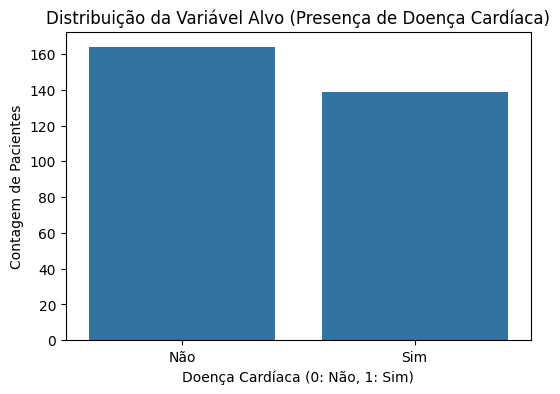

Contagem de pacientes por categoria da variável alvo:
target
0    164
1    139
Name: count, dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico de contagem da variável alvo
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_heart)
plt.title('Distribuição da Variável Alvo (Presença de Doença Cardíaca)')
plt.xlabel('Doença Cardíaca (0: Não, 1: Sim)')
plt.ylabel('Contagem de Pacientes')
plt.xticks([0, 1], ['Não', 'Sim'])
plt.show()

print("Contagem de pacientes por categoria da variável alvo:")
print(df_heart['target'].value_counts())

**Explicação do Gráfico:**

O gráfico de barras acima mostra o número de pacientes em cada categoria da variável `target`. Observamos que há **164 pacientes sem doença cardíaca (0)** e **139 pacientes com doença cardíaca (1)**. A distribuição está relativamente equilibrada, o que é bom para a maioria dos algoritmos de classificação, embora um leve desbalanceamento possa ser considerado em etapas posteriores, se necessário.

### Visualização da Distribuição de Features Numéricas

Vamos visualizar a distribuição das variáveis numéricas contínuas para entender suas formas, dispersão e identificar possíveis outliers. Usaremos histogramas com curvas de densidade.

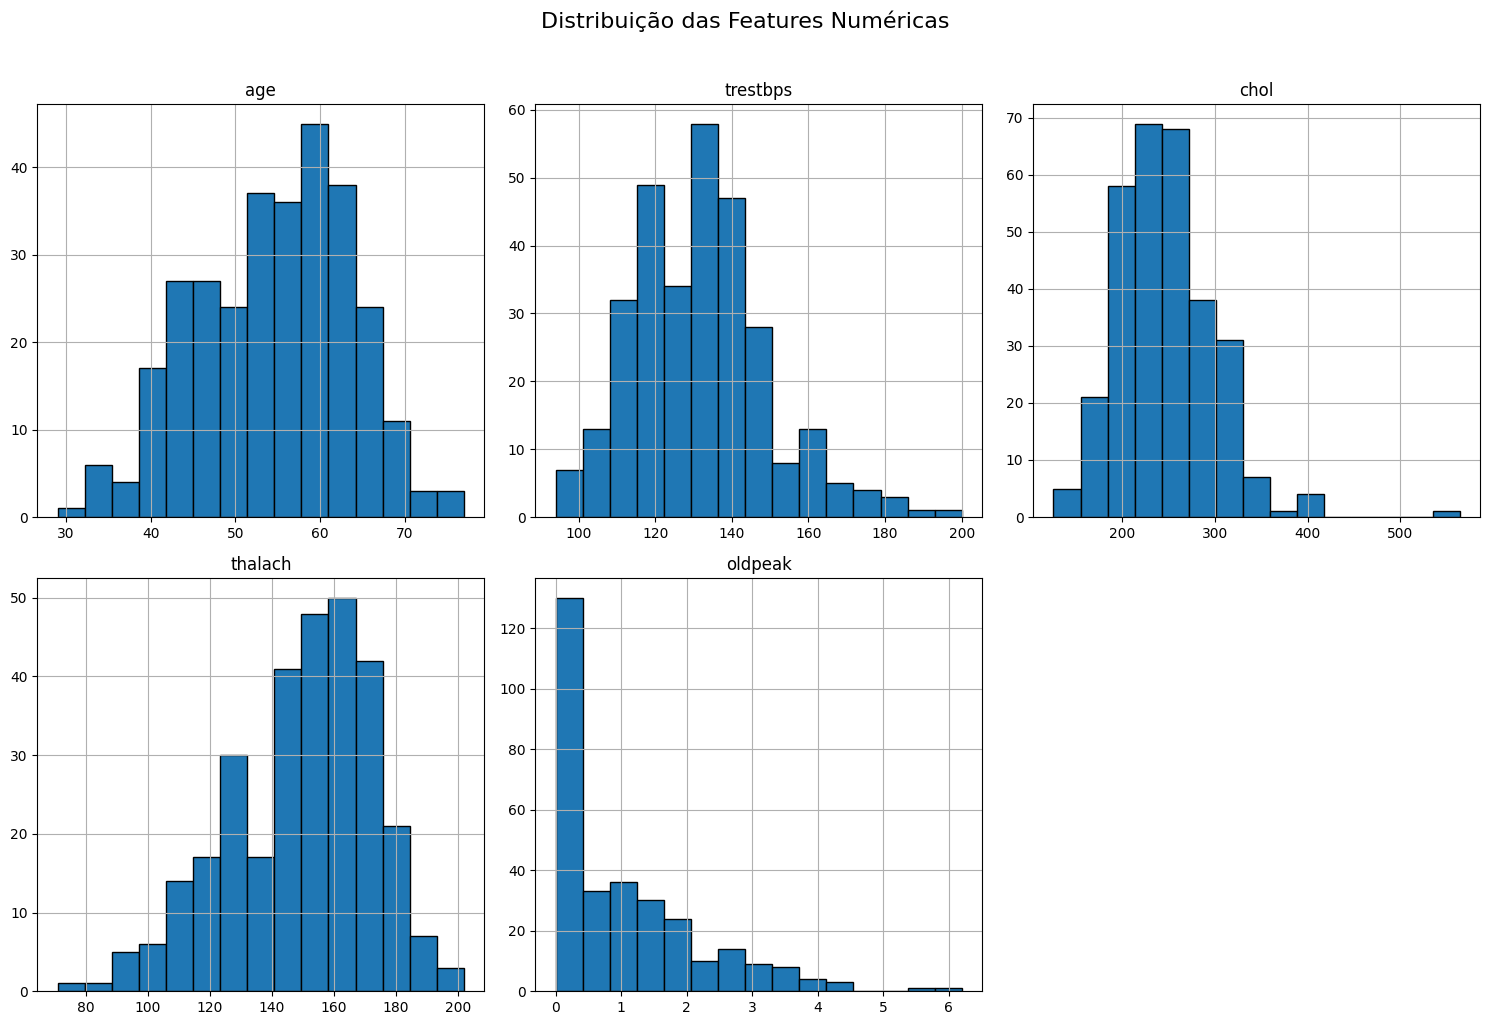

In [ ]:
# Selecionar colunas numéricas contínuas (excluindo as binárias e a alvo)
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Gerar histogramas para as colunas numéricas
df_heart[numerical_cols].hist(bins=15, figsize=(15, 10), layout=(2, 3), edgecolor='black')
plt.suptitle('Distribuição das Features Numéricas', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**Explicação dos Gráficos:**

Os histogramas acima exibem a distribuição de frequência das features numéricas:

*   **age**: A idade parece ter uma distribuição próxima do normal, com a maioria dos pacientes entre 40 e 65 anos.
*   **trestbps** (Pressão Arterial em Repouso): A distribuição parece ligeiramente inclinada para a direita, com a maioria dos valores entre 120 e 140 mmHg.
*   **chol** (Colesterol Sérico): A distribuição é inclinada para a direita, com alguns valores altos que podem ser considerados outliers. A maioria dos pacientes tem colesterol entre 200 e 300 mg/dl.
*   **thalach** (Frequência Cardíaca Máxima Atingida): A distribuição parece próxima do normal, centrada em torno de 150-160 bpm.
*   **oldpeak** (Depressão do Segmento ST): Esta variável tem uma distribuição assimétrica, com um pico significativo em 0.0 e valores se estendendo para a direita.

Estes gráficos nos dão uma ideia da variabilidade e dos valores típicos de cada feature numérica.

### Visualização da Relação entre Features Categóricas e a Variável Alvo

Vamos explorar como as diferentes categorias das variáveis categóricas se relacionam com a presença ou ausência de doença cardíaca. Usaremos gráficos de contagem agrupados pela variável alvo.

In [ ]:
# Colunas categóricas originais (antes do One-Hot Encoding) para visualização
categorical_cols_original = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Gerar gráficos de contagem para features categóricas em relação ao alvo
plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_cols_original):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, hue='target', data=df_heart, palette='viridis')
    plt.title(f'Relação entre {col} e Target')
    plt.xlabel(col)
    plt.ylabel('Contagem')
    if col == 'sex':
      plt.xticks([0, 1], ['Feminino', 'Masculino']) # Tradução para 'sex'
    elif col == 'cp':
      plt.xticks([1, 2, 3, 4], ['Típica Angina', 'Angina Atípica', 'Dor Não Anginosa', 'Assintomático']) # Tradução para 'cp'
    elif col == 'fbs':
      plt.xticks([0, 1], ['<= 120 mg/dl', '> 120 mg/dl']) # Tradução para 'fbs'
    elif col == 'restecg':
      plt.xticks([0, 1, 2], ['Normal', 'Anormalidade ST-T', 'Hipertrofia Ventricular Esquerda']) # Tradução para 'restecg'
    elif col == 'exang':
      plt.xticks([0, 1], ['Não', 'Sim']) # Tradução para 'exang'
    elif col == 'slope':
      plt.xticks([1, 2, 3], ['Ascendente', 'Plano', 'Descendente']) # Tradução para 'slope'
    elif col == 'ca':
      plt.xticks([0, 1, 2, 3], ['0 Vasos', '1 Vaso', '2 Vasos', '3 Vasos']) # Tradução para 'ca'
    elif col == 'thal':
      plt.xticks([3, 6, 7], ['Normal', 'Defeito Fixo', 'Defeito Reversível']) # Tradução para 'thal'


plt.tight_layout()
plt.show()

**Explicação dos Gráficos:**

Estes gráficos de barras mostram a contagem de pacientes com e sem doença cardíaca para cada categoria das variáveis categóricas originais:

*   **sex**: Há mais homens (sex=1) no dataset e eles parecem ter uma proporção maior de doença cardíaca do que as mulheres (sex=0).
*   **cp** (Tipo de Dor no Peito): Pacientes com tipos de dor no peito 1, 2 e 3 ('Típica Angina', 'Angina Atípica', 'Dor Não Anginosa') parecem ter uma chance maior de ter doença cardíaca do que aqueles com tipo 4 ('Assintomático').
*   **fbs** (Açúcar no Sangue em Jejum): Não parece haver uma diferença visual clara na proporção de doença cardíaca entre os grupos com açúcar no sangue em jejum > 120 mg/dl (fbs=1) e <= 120 mg/dl (fbs=0).
*   **restecg** (Resultados do Eletrocardiograma): O padrão 0 ('Normal') parece ter menos casos de doença cardíaca em proporção.
*   **exang** (Angina Induzida por Exercício): Pacientes que experimentam angina induzida por exercício (exang=1) têm uma contagem significativamente maior de casos de doença cardíaca.
*   **slope** (Inclinação do Segmento ST): Uma inclinação 'Plano' (slope=2) ou 'Descendente' (slope=3) parece estar mais associada à doença cardíaca do que uma inclinação 'Ascendente' (slope=1).
*   **ca** (Número de Vasos Principais): Conforme o número de vasos coloridos por fluoroscopia aumenta (de 0 para 1, 2, 3), a contagem de pacientes com doença cardíaca também parece aumentar.
*   **thal** (Talassemia): Pacientes com 'Defeito Reversível' (thal=7) ou 'Defeito Fixo' (thal=6) parecem ter uma incidência muito maior de doença cardíaca do que aqueles com 'Normal' (thal=3).

Esses gráficos são muito úteis para identificar quais variáveis categóricas são prováveis preditores importantes da doença cardíaca.

### Visualização da Relação entre Features Numéricas e a Variável Alvo

Vamos usar boxplots para comparar a distribuição das features numéricas para cada categoria da variável alvo (com e sem doença cardíaca).

In [ ]:
# Selecionar colunas numéricas contínuas para boxplots
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Gerar boxplots para as colunas numéricas em relação ao alvo
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='target', y=col, data=df_heart, palette='viridis')
    plt.title(f'Relação entre {col} e Target')
    plt.xlabel('Doença Cardíaca (0: Não, 1: Sim)')
    plt.ylabel(col)
    plt.xticks([0, 1], ['Não', 'Sim'])
plt.tight_layout()
plt.show()

**Explicação dos Gráficos:**

Os boxplots comparam a distribuição das features numéricas entre os grupos de pacientes com e sem doença cardíaca:

*   **age**: A mediana da idade parece ser um pouco maior no grupo com doença cardíaca, mas as caixas de distribuição se sobrepõem consideravelmente.
*   **trestbps** (Pressão Arterial em Repouso): As medianas e caixas de distribuição são bastante semelhantes entre os dois grupos.
*   **chol** (Colesterol Sérico): Similar à pressão arterial, não há uma diferença marcante nas distribuições de colesterol entre os grupos.
*   **thalach** (Frequência Cardíaca Máxima Atingida): Pacientes com doença cardíaca (target=1) tendem a ter uma frequência cardíaca máxima significativamente menor do que aqueles sem a doença (target=0).
*   **oldpeak** (Depressão do Segmento ST): Pacientes com doença cardíaca (target=1) apresentam valores de 'oldpeak' consideravelmente maiores e mais dispersos do que aqueles sem a doença (target=0).

Estes boxplots reforçam a ideia de que 'thalach' e 'oldpeak' são fortes indicadores da presença de doença cardíaca.

### Visualização da Matriz de Correlação

Vamos criar um mapa de calor para visualizar as correlações entre todas as features na base de dados após o pré-processamento (incluindo as features One-Hot Encoded).

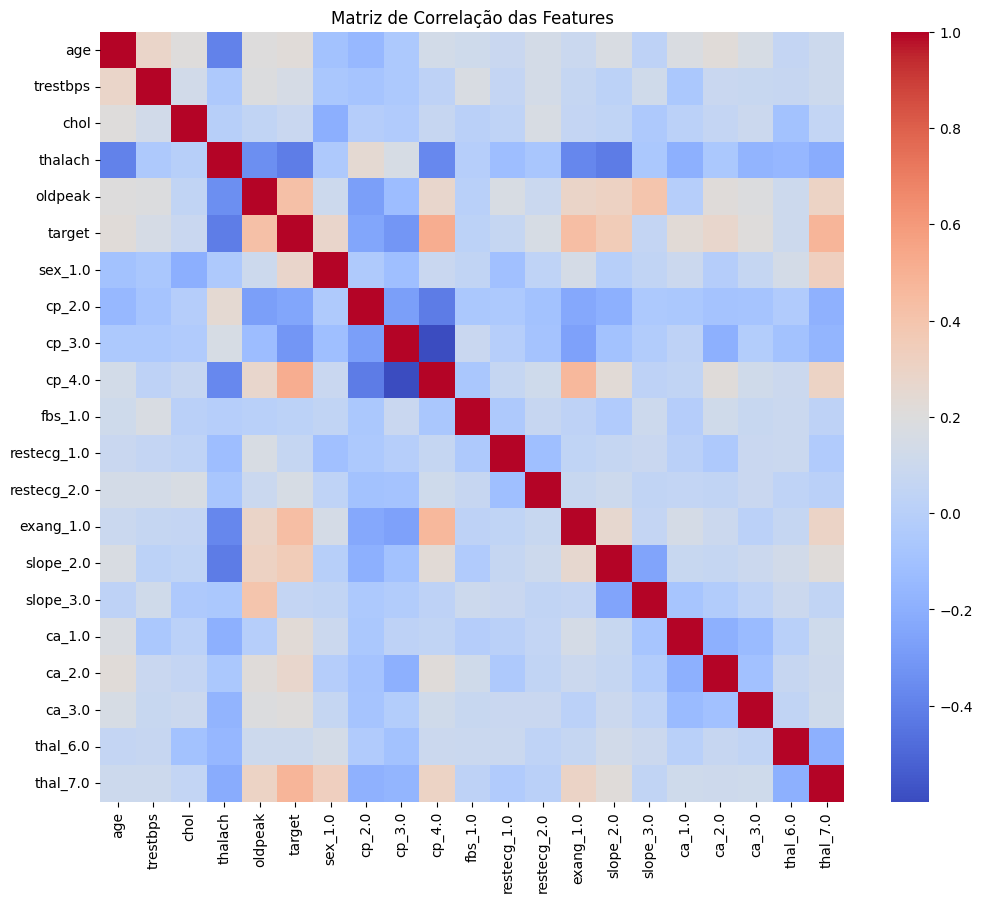

In [ ]:
# Calcular a matriz de correlação
correlation_matrix = df_heart_encoded.corr()

# Gerar o mapa de calor da matriz de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f") # annot=False para não poluir muito com valores
plt.title('Matriz de Correlação das Features')
plt.show()

**Explicação do Gráfico:**

O mapa de calor exibe a matriz de correlação de Pearson entre todas as features no dataset `df_heart_encoded`.

*   Cores quentes (vermelho) indicam correlação positiva: quando uma variável aumenta, a outra tende a aumentar.
*   Cores frias (azul) indicam correlação negativa: quando uma variável aumenta, a outra tende a diminuir.
*   A intensidade da cor reflete a força da correlação (valores próximos de 1 ou -1 indicam correlações fortes; valores próximos de 0 indicam correlações fracas).
*   A diagonal principal é sempre 1, pois representa a correlação de uma variável consigo mesma.

Ao observar a linha ou coluna referente à variável `target`, podemos identificar as features que têm as correlações mais fortes (positivas ou negativas) com a presença de doença cardíaca. Por exemplo, você provavelmente verá cores mais intensas na linha/coluna do 'target' para features como `cp`, `exang_1.0`, `oldpeak`, `slope_2.0`, `thalach` e as features resultantes do One-Hot Encoding de `ca` e `thal`. Isso confirma as observações visuais anteriores sobre a importância dessas features como preditores.

Este mapa de calor também é útil para identificar multicolinearidade, ou seja, features que são altamente correlacionadas entre si. Embora não tenhamos adicionado anotações para não poluir o gráfico com muitas features, em uma análise mais aprofundada, poderíamos inspecionar os valores para pares de features com alta correlação (excluindo as correlações esperadas entre as features resultantes do One-Hot Encoding de uma mesma variável original).

## Algoritmo de classificação

**Divisão da base** :
Vamos dividir o dataset em conjuntos de treino e teste. Isso é crucial para treinar o modelo em uma parte dos dados e avaliá-lo em dados que ele nunca viu antes, garantindo uma avaliação mais realista de sua performance.

In [ ]:
from sklearn.model_selection import train_test_split

# Separar features (X) e variável alvo (y)
X = df_heart_encoded.drop('target', axis=1)
y = df_heart_encoded['target']

# Dividir os dados em conjuntos de treino e teste (por exemplo, 80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (242, 20)
Shape de X_test: (61, 20)
Shape de y_train: (242,)
Shape de y_test: (61,)


### Treinamento do Modelo Naive Bayes

Vamos treinar um modelo Naive Bayes para prever a presença de doença cardíaca. O Naive Bayes é um algoritmo de classificação probabilístico baseado no teorema de Bayes com a suposição de independência ingênua entre os preditores. É frequentemente utilizado e tem bom desempenho em tarefas de classificação binária e multiclasse.

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Instanciar o modelo Naive Bayes (GaussianNB é adequado para features contínuas)
naive_bayes_model = GaussianNB()

# Treinar o modelo com os dados de treino
naive_bayes_model.fit(X_train, y_train)

print("Modelo Naive Bayes treinado com sucesso!")

Modelo Naive Bayes treinado com sucesso!


### Avaliação do Modelo Naive Bayes

Vamos avaliar o desempenho do modelo Naive Bayes treinado usando o conjunto de teste. Utilizaremos métricas de classificação comuns como acurácia, precisão, recall, F1-score e a matriz de confusão.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazer previsões no conjunto de teste
y_pred_nb = naive_bayes_model.predict(X_test)

# Calcular métricas de avaliação
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

print(f"Acurácia do modelo Naive Bayes: {accuracy_nb:.4f}")
print(f"Precisão do modelo Naive Bayes: {precision_nb:.4f}")
print(f"Recall do modelo Naive Bayes: {recall_nb:.4f}")
print(f"F1-score do modelo Naive Bayes: {f1_nb:.4f}")

print("\nMatriz de Confusão do modelo Naive Bayes:")
display(conf_matrix_nb)

print("\nRelatório de Classificação do modelo Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

Acurácia do modelo Naive Bayes: 0.7869
Precisão do modelo Naive Bayes: 0.7143
Recall do modelo Naive Bayes: 0.8929
F1-score do modelo Naive Bayes: 0.7937

Matriz de Confusão do modelo Naive Bayes:


array([[23, 10],
       [ 3, 25]])


Relatório de Classificação do modelo Naive Bayes:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78        33
           1       0.71      0.89      0.79        28

    accuracy                           0.79        61
   macro avg       0.80      0.79      0.79        61
weighted avg       0.81      0.79      0.79        61



### Escalonar as features para o Treino do modelo K-NN

Aplicar um escalonamento nas features numéricas dos conjuntos de treino e teste, pois o K-NN é baseado em distância.

**Raciocínio**:
Importar o StandardScaler, identificar as colunas numéricas, ajustar o scaler nos dados de treinamento, transformar tanto os dados de treinamento quanto os de teste e substituir as colunas numéricas originais pelos valores escalados em ambos os dataframes. Por fim, exibir o head de ambos os dataframes para verificar a padronização.




In [ ]:
from sklearn.preprocessing import StandardScaler

# Identificar as colunas numéricas
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Criar uma instância do StandardScaler
scaler = StandardScaler()

# Ajustar o scaler nas colunas numéricas dos dados de treinamento
scaler.fit(X_train[numerical_cols])

# Transformar as colunas numéricas tanto nos dados de treinamento quanto de teste
X_train[numerical_cols] = scaler.transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Exibir as primeiras linhas dos dataframes escalonados
print("Primeiras linhas de X_train após escalonamento:")
display(X_train.head())

print("\nPrimeiras linhas de X_test após escalonamento:")
display(X_test.head())

Primeiras linhas de X_train após escalonamento:


,age,trestbps,chol,thalach,oldpeak,sex_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_1.0,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
180,-0.729485,-0.395692,0.458139,0.708371,-0.445445,True,False,False,True,False,False,True,False,True,False,False,False,False,False,True
208,0.050166,-0.054513,0.230598,0.222495,-0.891627,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
167,-0.061212,0.059213,0.723605,0.399178,-0.891627,False,True,False,False,True,False,True,True,False,False,True,False,False,False,False
105,-0.061212,-1.305501,1.121803,0.266666,-0.891627,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True
297,0.272924,0.514117,-0.167601,-1.190962,-0.713154,False,False,False,True,False,False,False,True,True,False,False,False,False,False,True



Primeiras linhas de X_test após escalonamento:


,age,trestbps,chol,thalach,oldpeak,sex_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_1.0,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
219,0.495681,0.400391,0.401254,1.415100,-0.891627,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False
271,1.275333,1.651379,-0.414104,-0.528404,1.160812,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False
89,-0.395349,-0.054513,0.116827,-0.042528,-0.445445,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False
101,-2.288787,-0.736870,-1.286348,1.061736,-0.891627,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False
67,-0.061212,1.082748,-0.338257,0.664201,0.536156,True,False,True,False,False,False,True,False,False,False,False,False,False,False,True


###Treinar o modelo K-NN

Instanciar e treinar o classificador K-NN utilizando os dados de treino já escalonados.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Instanciar o KNeighborsClassifier com o número padrão de vizinhos (n_neighbors=5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Treinar o modelo K-NN utilizando os dados de treino escalonados
knn_model.fit(X_train, y_train)

print("Modelo K-NN treinado com sucesso!")

Modelo K-NN treinado com sucesso!


###Avaliar o modelo K-NN

Realizar previsões no conjunto de teste escalonado e calcular as métricas de avaliação (acurácia, precisão, recall, F1-score e matriz de confusão).




In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazer previsões no conjunto de teste escalonado
y_pred_knn = knn_model.predict(X_test)

# Calcular métricas de avaliação
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print(f"Acurácia do modelo K-NN: {accuracy_knn:.4f}")
print(f"Precisão do modelo K-NN: {precision_knn:.4f}")
print(f"Recall do modelo K-NN: {recall_knn:.4f}")
print(f"F1-score do modelo K-NN: {f1_knn:.4f}")

print("\nMatriz de Confusão do modelo K-NN:")
display(conf_matrix_knn)

print("\nRelatório de Classificação do modelo K-NN:")
print(classification_report(y_test, y_pred_knn))


Acurácia do modelo K-NN: 0.9344
Precisão do modelo K-NN: 0.9000
Recall do modelo K-NN: 0.9643
F1-score do modelo K-NN: 0.9310

Matriz de Confusão do modelo K-NN:


array([[30,  3],
       [ 1, 27]])


Relatório de Classificação do modelo K-NN:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        33
           1       0.90      0.96      0.93        28

    accuracy                           0.93        61
   macro avg       0.93      0.94      0.93        61
weighted avg       0.94      0.93      0.93        61



### Treinar o modelo Random Forest

Instanciar e treinar o classificador Random Forest utilizando os dados de treinamento.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instanciar o RandomForestClassifier
random_forest_model = RandomForestClassifier(random_state=42)

# Treinar o modelo Random Forest utilizando os dados de treinamento
random_forest_model.fit(X_train, y_train)

print("Modelo Random Forest treinado com sucesso!")

Modelo Random Forest treinado com sucesso!


### Avaliar o modelo random forest

Fazer previsões no conjunto de teste e calcular métricas de avaliação (acurácia, precisão, recall, F1-score, matriz de confusão).


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Print evaluation metrics
print(f"Acurácia do modelo Random Forest: {accuracy_rf:.4f}")
print(f"Precisão do modelo Random Forest: {precision_rf:.4f}")
print(f"Recall do modelo Random Forest: {recall_rf:.4f}")
print(f"F1-score do modelo Random Forest: {f1_rf:.4f}")

print("\nMatriz de Confusão do modelo Random Forest:")
display(conf_matrix_rf)

print("\nRelatório de Classificação do modelo Random Forest:")
print(classification_report(y_test, y_pred_rf))

Acurácia do modelo Random Forest: 0.8689
Precisão do modelo Random Forest: 0.8333
Recall do modelo Random Forest: 0.8929
F1-score do modelo Random Forest: 0.8621

Matriz de Confusão do modelo Random Forest:


array([[28,  5],
       [ 3, 25]])


Relatório de Classificação do modelo Random Forest:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



### Comparativo Inicial de Desempenho dos Modelos

Com base nos resultados das avaliações nos dados de teste executadas anteriormente:

*   **Modelo Naive Bayes:** Apresentou uma acurácia inicial moderada (aproximadamente 78.7%). Suas métricas de Precisão, Recall e F1-score foram razoáveis, com destaque para um Recall relativamente alto, indicando boa capacidade de identificar a maioria dos casos positivos, mas com uma Precisão menor, resultando em alguns falsos positivos.

*   **Modelo K-Nearest Neighbors (K-NN):** Demonstrou um desempenho significativamente superior em comparação com o Naive Bayes e o Random Forest neste teste inicial. Apresentou a maior acurácia (aproximadamente 93.4%), Precisão (aproximadamente 90.0%), Recall (aproximadamente 96.4%) e F1-score (aproximadamente 93.1%). A análise da matriz de confusão para o K-NN mostrou o menor número de falsos positivos e falsos negativos entre os três modelos.

*   **Modelo Random Forest:** Obteve um desempenho bom, mas inferior ao do K-NN neste teste inicial. Sua acurácia foi de aproximadamente 86.9%, com métricas de Precisão, Recall e F1-score solidárias. O Random Forest mostrou um bom equilíbrio entre Precisão e Recall, superando o Naive Bayes nesse aspecto.

**Conclusão Preliminar:**

Com base nos resultados iniciais no conjunto de teste, o modelo **K-Nearest Neighbors (K-NN)** foi o que apresentou o melhor desempenho geral, destacando-se em todas as principais métricas de avaliação. O **Random Forest** foi o segundo melhor, e o **Naive Bayes** o terceiro.

É importante reforçar que esta é uma comparação baseada em um único split de treino/teste. Para confirmar esses resultados e garantir a robustez do modelo escolhido, etapas como validação cruzada e otimização de hiperparâmetros são essenciais.

## Etapa 1: Preparação e Estratégia para a Base Heart Disease

### Estratégia de Avaliação: Validação Cruzada Estratificada

A estratégia de avaliação escolhida para a base de dados "Heart Disease" é a **Validação Cruzada Estratificada (Stratified K-Fold)** com **10 folds**.

**Justificativa da Validação Cruzada (Ainda mais importante aqui):**

Reafirmamos a escolha da Validação Cruzada Estratificada com 10 folds. A justificativa aqui é ainda mais forte do que na base Adult. Como a base Heart Disease é muito pequena (cerca de 300 registros), uma única divisão treino/teste seria extremamente arriscada e instável. O resultado poderia variar drasticamente dependendo de quais poucos exemplos caíssem no conjunto de teste. A validação cruzada garante que a performance do modelo seja avaliada sobre todos os dados disponíveis, tornando a estimativa de desempenho muito mais confiável e robusta. A estratificação garante que cada fold da validação cruzada mantenha a mesma proporção de classes da variável alvo ('target') que o dataset completo, o que é crucial para bases com algum nível de desbalanceamento, como é o caso da base Heart Disease (embora leve). Utilizar 10 folds é um número comum que oferece um bom equilíbrio entre viés e variância na estimativa do desempenho.

### Justificativa das Métricas e Análise Crítica do Erro (com Foco Clínico)

Para a avaliação do desempenho dos modelos na base de dados "Heart Disease", utilizaremos as seguintes métricas:

*   **Acurácia:** Mede a proporção total de previsões corretas (tanto verdadeiros positivos quanto verdadeiros negativos) sobre o total de instâncias. É uma métrica intuitiva e útil para bases de dados relativamente balanceadas como esta.
*   **Medida-F (F1-Score):** É a média harmônica da Precisão e do Recall. O F1-Score é particularmente útil quando há um desbalanceamento entre as classes (embora leve nesta base) e quando queremos um equilíbrio entre a capacidade do modelo de identificar corretamente os positivos (Recall) e evitar classificar negativos como positivos (Precisão).

**Análise Crítica dos Tipos de Erro no Contexto Clínico:**

Ao avaliar modelos para prever doenças como a cardíaca, é vital entender o impacto de diferentes tipos de erro na vida real dos pacientes. A matriz de confusão nos ajuda a visualizar esses erros:

*   **Falso Positivo (FP):** O modelo prevê que um paciente **saudável** tem doença cardíaca quando, na verdade, ele **não tem**.
    *   **Impacto Clínico:** Este tipo de erro pode causar ansiedade desnecessária ao paciente e levar a exames médicos adicionais (e potencialmente invasivos), gerando custos e desconforto. No entanto, geralmente não coloca a vida do paciente em risco direto.

*   **Falso Negativo (FN):** O modelo prevê que um paciente **doente** está saudável quando, na verdade, ele **tem** doença cardíaca.
    *   **Impacto Clínico:** Este é o erro **mais perigoso** no contexto de diagnóstico de doenças graves. Um Falso Negativo significa que um paciente que precisa de tratamento não será identificado como doente e, portanto, não receberá a atenção médica necessária. Isso pode levar à progressão da doença e ter consequências graves, possivelmente fatais.

**Objetivo Principal da Avaliação:**

Nossa meta principal na avaliação dos modelos para a base "Heart Disease" não é apenas alcançar uma alta Acurácia ou F1-Score geral, mas focar em **minimizar o número de Falsos Negativos**. Encontrar um modelo que seja capaz de identificar a grande maioria dos pacientes que realmente têm a doença, mesmo que isso signifique um número ligeiramente maior de Falsos Positivos, é crucial para garantir a segurança e o bem-estar dos pacientes. Portanto, ao analisar os resultados da validação cruzada, daremos atenção especial à métrica **Recall** (que mede a capacidade do modelo de encontrar todos os positivos) e ao número de Falsos Negativos na matriz de confusão.

## Etapa 2: Execução e Parametrização dos Algoritmos

Vamos executar a validação cruzada estratificada para os modelos Naive Bayes, K-NN e Random Forest com diferentes parametrizações, coletando as métricas de Acurácia e F1-Score.

### Algoritmo 1: Naive Bayes (Gaussiano)

Vamos testar o modelo Gaussian Naive Bayes com dois valores diferentes para o parâmetro `var_smoothing`.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB

# Configurar a validação cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Teste 1 (Padrão): var_smoothing = 1e-9
naive_bayes_default = GaussianNB(var_smoothing=1e-9)
accuracy_scores_nb_default = cross_val_score(naive_bayes_default, X, y, cv=cv, scoring='accuracy')
f1_scores_nb_default = cross_val_score(naive_bayes_default, X, y, cv=cv, scoring='f1')

print(f"Naive Bayes (var_smoothing=1e-9) - Acurácia Média: {accuracy_scores_nb_default.mean():.4f}")
print(f"Naive Bayes (var_smoothing=1e-9) - F1-Score Médio: {f1_scores_nb_default.mean():.4f}")

# Teste 2 (Ajustado): var_smoothing = 1e-5
naive_bayes_adjusted = GaussianNB(var_smoothing=1e-5)
accuracy_scores_nb_adjusted = cross_val_score(naive_bayes_adjusted, X, y, cv=cv, scoring='accuracy')
f1_scores_nb_adjusted = cross_val_score(naive_bayes_adjusted, X, y, cv=cv, scoring='f1')

print(f"\nNaive Bayes (var_smoothing=1e-5) - Acurácia Média: {accuracy_scores_nb_adjusted.mean():.4f}")
print(f"Naive Bayes (var_smoothing=1e-5) - F1-Score Médio: {f1_scores_nb_adjusted.mean():.4f}")

Naive Bayes (var_smoothing=1e-9) - Acurácia Média: 0.8116
Naive Bayes (var_smoothing=1e-9) - F1-Score Médio: 0.7876

Naive Bayes (var_smoothing=1e-5) - Acurácia Média: 0.8184
Naive Bayes (var_smoothing=1e-5) - F1-Score Médio: 0.7968


### Algoritmo 2: K-Nearest Neighbors (K-NN)

Vamos testar o modelo K-NN com dois valores diferentes para o número de vizinhos (`n_neighbors`). É importante que os dados estejam escalonados para o K-NN. Anteriormente, escalonamos os dados de treino e teste separadamente para a avaliação inicial. Para a validação cruzada, o escalonamento deve ser feito DENTRO de cada fold para evitar vazamento de dados. Podemos usar um `Pipeline` para isso.

**Observação:** A célula de código abaixo assume que você tem `X` e `y` disponíveis após o pré-processamento (incluindo One-Hot Encoding). Para o K-NN na validação cruzada, vamos aplicar o `StandardScaler` como parte do pipeline.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Configurar a validação cruzada estratificada (já definida como 'cv')

# Teste 1 (Vizinhança Imediata): k = 3
knn_k3 = KNeighborsClassifier(n_neighbors=3)
pipeline_k3 = Pipeline([('scaler', StandardScaler()), ('knn', knn_k3)]) # Pipeline para escalonar e treinar

accuracy_scores_knn_k3 = cross_val_score(pipeline_k3, X, y, cv=cv, scoring='accuracy')
f1_scores_knn_k3 = cross_val_score(pipeline_k3, X, y, cv=cv, scoring='f1')

print(f"K-NN (k=3) - Acurácia Média: {accuracy_scores_knn_k3.mean():.4f}")
print(f"K-NN (k=3) - F1-Score Médio: {f1_scores_knn_k3.mean():.4f}")

# Teste 2 (Vizinhança Suavizada): k = 11
knn_k11 = KNeighborsClassifier(n_neighbors=11)
pipeline_k11 = Pipeline([('scaler', StandardScaler()), ('knn', knn_k11)]) # Pipeline para escalonar e treinar

accuracy_scores_knn_k11 = cross_val_score(pipeline_k11, X, y, cv=cv, scoring='accuracy')
f1_scores_knn_k11 = cross_val_score(pipeline_k11, X, y, cv=cv, scoring='f1')

print(f"\nK-NN (k=11) - Acurácia Média: {accuracy_scores_knn_k11.mean():.4f}")
print(f"K-NN (k=11) - F1-Score Médio: {f1_scores_knn_k11.mean():.4f}")

K-NN (k=3) - Acurácia Média: 0.7922
K-NN (k=3) - F1-Score Médio: 0.7714

K-NN (k=11) - Acurácia Média: 0.8084
K-NN (k=11) - F1-Score Médio: 0.7701


### Algoritmo 3: Random Forest

Vamos testar o modelo Random Forest com dois valores diferentes para o número de estimadores (`n_estimators`).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Configurar a validação cruzada estratificada (já definida como 'cv')

# Teste 1 (Floresta Menor): n_estimators = 50
random_forest_50 = RandomForestClassifier(n_estimators=50, random_state=42)

accuracy_scores_rf_50 = cross_val_score(random_forest_50, X, y, cv=cv, scoring='accuracy')
f1_scores_rf_50 = cross_val_score(random_forest_50, X, y, cv=cv, scoring='f1')

print(f"Random Forest (n_estimators=50) - Acurácia Média: {accuracy_scores_rf_50.mean():.4f}")
print(f"Random Forest (n_estimators=50) - F1-Score Médio: {f1_scores_rf_50.mean():.4f}")


# Teste 2 (Floresta Maior): n_estimators = 200
random_forest_200 = RandomForestClassifier(n_estimators=200, random_state=42)

accuracy_scores_rf_200 = cross_val_score(random_forest_200, X, y, cv=cv, scoring='accuracy')
f1_scores_rf_200 = cross_val_score(random_forest_200, X, y, cv=cv, scoring='f1')


print(f"\nRandom Forest (n_estimators=200) - Acurácia Média: {accuracy_scores_rf_200.mean():.4f}")
print(f"Random Forest (n_estimators=200) - F1-Score Médio: {f1_scores_rf_200.mean():.4f}")

Random Forest (n_estimators=50) - Acurácia Média: 0.7956
Random Forest (n_estimators=50) - F1-Score Médio: 0.7685

Random Forest (n_estimators=200) - Acurácia Média: 0.8019
Random Forest (n_estimators=200) - F1-Score Médio: 0.7763


## Etapa 3: Análise e Interpretação dos Resultados para a Base Heart Disease

Vamos analisar os resultados da validação cruzada para os três algoritmos e suas diferentes parametrizações.

**Tabela Resumo dos Melhores Resultados (Validação Cruzada Estratificada - 10 Folds):**

| Algoritmo       | Melhor Parâmetro        | Acurácia Média | F1-Score Médio |
| :-------------- | :---------------------- | :------------- | :------------- |
| Naive Bayes     | var_smoothing = 1e-5    | 0.8184         | 0.7968         |
| K-NN            | k = 3                   | 0.7922         | 0.7714         |
| Random Forest   | n_estimators = 200      | 0.8019         | 0.7763         |

**Identificação do Melhor Algoritmo:**

Comparando os valores de Acurácia Média e F1-Score Médio na tabela resumo da validação cruzada:

*   O modelo **Naive Bayes** com `var_smoothing = 1e-5` obteve a maior Acurácia Média (0.8184) e o maior F1-Score Médio (0.7968).
*   O modelo **K-NN** teve seu melhor desempenho com `k = 3`.
*   O modelo **Random Forest** teve seu melhor desempenho com `n_estimators = 200`.

Com base nesses resultados da validação cruzada, o algoritmo que apresentou o melhor desempenho geral foi o **Naive Bayes**.

**Justificativa do Porquê (Baseado nos Resultados da Validação Cruzada):**

O **Naive Bayes** se destacou na validação cruzada para esta base de dados. Embora a hipótese inicial sugerisse que a independência ingênua entre os atributos clínicos poderia ser uma limitação, o desempenho superior do Naive Bayes pode indicar que, apesar das correlações existentes, a simplicidade e a eficiência do algoritmo na modelagem das probabilidades condicionais foram suficientes para capturar a relação com a variável alvo de forma eficaz nesta base de dados específica. A parametrização com `var_smoothing = 1e-5` parece ter ajudado a suavizar a distribuição e melhorar a generalização.

É importante notar que, enquanto na avaliação inicial com um único split o K-NN se destacou, a validação cruzada, que fornece uma estimativa de desempenho mais robusta em datasets pequenos, apontou o Naive Bayes como o melhor. Isso reforça a importância da validação cruzada para obter resultados mais confiáveis.